In [1]:
# cell 0
import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import ParameterGrid
from sklearn.utils import resample
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cell 1
X = pd.read_parquet("/kaggle/input/anomaly-data/features_v1.parquet")

# Drop identifiers
X = X.drop(columns=["CLM_ID", "DESYNPUF_ID"], errors="ignore")

# Cyclical encoding
X["month_sin"] = np.sin(2 * np.pi * X["month"] / 12)
X["month_cos"] = np.cos(2 * np.pi * X["month"] / 12)
X["dow_sin"]   = np.sin(2 * np.pi * X["day_of_week"] / 7)
X["dow_cos"]   = np.cos(2 * np.pi * X["day_of_week"] / 7)

X = X.drop(columns=["month", "day_of_week", "quarter"], errors="ignore")

X = X.fillna(0)

In [3]:
X.head()

,log_payment,payment_zscore,high_cost_flag,zero_payment_flag,claim_duration,weekend_flag,procedure_count,total_code_count,provider_claim_volume,provider_avg_payment,high_volume_provider_flag,month_sin,month_cos,dow_sin,dow_cos
0,3.713572,-0.427195,0,0,0,0,48,59,112,322.857143,1,5.000000e-01,-0.866025,0.974928,-0.222521
1,3.931826,-0.409369,0,0,0,0,48,59,8,166.250000,0,8.660254e-01,-0.500000,0.974928,-0.222521
2,4.510860,-0.338063,0,0,0,1,48,59,149,296.442953,1,-8.660254e-01,-0.500000,-0.781831,0.623490
3,5.707110,0.036291,0,0,0,1,48,59,76,267.368421,0,-2.449294e-16,1.000000,-0.781831,0.623490
4,5.303305,-0.141973,0,0,0,1,48,59,69,225.217391,0,5.000000e-01,0.866025,-0.781831,0.623490


In [4]:
# cell 2-scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
#cell 3- anomalies 3%
def top_frac_mask(scores, frac=0.03):
    k = int(len(scores) * frac)
    idx = np.argsort(scores)[-k:]
    mask = np.zeros(len(scores), dtype=bool)
    mask[idx] = True
    return mask

def top_frac_set(scores, frac=0.03):
    k = int(len(scores) * frac)
    return set(np.argsort(scores)[-k:])

def jaccard(a, b):
    return len(a & b) / len(a | b)

def stability_score(model_builder, X, frac=0.03, n_runs=5, sample_frac=0.8):
    overlaps = []
    prev = None
    
    for _ in range(n_runs):
        X_sub = resample(X, replace=False, n_samples=int(len(X) * sample_frac))
        model = model_builder()
        scores = -model.fit(X_sub).decision_function(X_sub)
        curr = top_frac_set(scores, frac)
        
        if prev is not None:
            overlaps.append(jaccard(prev, curr))
        prev = curr
    
    return float(np.mean(overlaps))

In [6]:
# cell 4 setting hyperparameters
if_grid = ParameterGrid({
    "n_estimators": [200, 400],
    "max_samples": [0.6, 0.8],
    "max_features": [0.5, 0.8],
    "contamination": [0.03]
})

svm_grid = ParameterGrid({
    "nu": [0.02, 0.03, 0.05],
    "gamma": ["scale", 0.1]
})

lof_grid = ParameterGrid({
    "n_neighbors": [20, 50, 100],
    "contamination": [0.03]
})

### Tuning models

In [7]:
# cell 5 - isolation forest tuning
if_results = []

for params in if_grid:
    def build_if():
        return IsolationForest(**params, random_state=42, n_jobs=-1)
    
    stab = stability_score(build_if, X_scaled, frac=0.03)
    if_results.append({**params, "stability": stab})

if_df = pd.DataFrame(if_results).sort_values("stability", ascending=False)
if_df.head()

,contamination,max_features,max_samples,n_estimators,stability
1,0.03,0.5,0.6,400,0.016052
4,0.03,0.8,0.6,200,0.015311
6,0.03,0.8,0.8,200,0.015004
7,0.03,0.8,0.8,400,0.014942
3,0.03,0.5,0.8,400,0.014573


### **cell 6 SVM tuning**
- SVM is tuned in quadratic time n^4. So, tuning the whole set is unfeasible. 

In [8]:
np.random.seed(42)
svm_idx = np.random.choice(len(X_scaled), 50000, replace=False)
X_svm_tune = X_scaled[svm_idx]

In [9]:
svm_results = []

for params in svm_grid:
    def build_svm():
        return OneClassSVM(kernel="rbf", **params)
    
    stab = stability_score(build_svm, X_svm_tune, frac=0.03)
    svm_results.append({**params, "stability": stab})

svm_df = pd.DataFrame(svm_results).sort_values("stability", ascending=False)
svm_df.head()

,gamma,nu,stability
2,scale,0.05,0.015880
0,scale,0.02,0.015879
4,0.1,0.03,0.015553
5,0.1,0.05,0.014695
1,scale,0.03,0.014483


In [10]:
best_svm_params = svm_df.iloc[0].drop("stability").to_dict()

best_svm = OneClassSVM(kernel="rbf", **best_svm_params)
best_svm.fit(X_scaled)  # try full data once

OneClassSVM(nu=0.05)

In [11]:
# cell 7 - LOF tuning
lof_results = []

for params in lof_grid:
    def build_lof():
        return LocalOutlierFactor(novelty=True, **params)
    
    stab = stability_score(build_lof, X_scaled, frac=0.03)
    lof_results.append({**params, "stability": stab})

lof_df = pd.DataFrame(lof_results).sort_values("stability", ascending=False)
lof_df.head()

,contamination,n_neighbors,stability
1,0.03,50,0.015557
0,0.03,20,0.015437
2,0.03,100,0.015343


In [12]:
# # cell 8 fitting each best model with full data. First convert integer parameters back to int
if_params = if_df.iloc[0].drop("stability").to_dict()
if_params["n_estimators"] = int(if_params["n_estimators"])
if_params["max_samples"] = float(if_params["max_samples"])  # stays float
if_params["max_features"] = float(if_params["max_features"])  # stays float

best_if  = IsolationForest(**if_params, random_state=42, n_jobs=-1)
best_svm = OneClassSVM(kernel="rbf", **svm_df.iloc[0].drop("stability").to_dict())
best_lof = LocalOutlierFactor(novelty=True, **lof_df.iloc[0].drop("stability").to_dict())

In [13]:
if_scores  = -best_if.fit(X_scaled).decision_function(X_scaled)

In [14]:
svm_scores = -best_svm.fit(X_scaled).decision_function(X_scaled)

In [15]:
lof_params = lof_df.iloc[0].drop("stability").to_dict()
lof_params["n_neighbors"] = int(lof_params["n_neighbors"])  # must be int

best_lof = LocalOutlierFactor(novelty=True, **lof_params)

In [16]:
lof_scores = -best_lof.fit(X_scaled).decision_function(X_scaled)

In [17]:
# cell 9 fair comparison between models with top 3
mask_if  = top_frac_mask(if_scores,  frac=0.03)
mask_svm = top_frac_mask(svm_scores, frac=0.03)
mask_lof = top_frac_mask(lof_scores, frac=0.03)

In [18]:
# cell 10 - Compare models (overlap + business signal)
def audit_stats(mask, X):
    return {
        "high_cost_rate": X.loc[mask, "high_cost_flag"].mean(),
        "zero_payment_rate": X.loc[mask, "zero_payment_flag"].mean(),
        "high_volume_provider_rate": X.loc[mask, "high_volume_provider_flag"].mean(),
        "avg_log_payment": X.loc[mask, "log_payment"].mean(),
        "count": int(mask.sum())
    }

audit_if  = audit_stats(mask_if,  X)
audit_svm = audit_stats(mask_svm, X)
audit_lof = audit_stats(mask_lof, X)

audit_if, audit_svm, audit_lof

({'high_cost_rate': np.float64(0.6813837920489296),
  'zero_payment_rate': np.float64(0.18501529051987767),
  'high_volume_provider_rate': np.float64(0.5498853211009175),
  'avg_log_payment': np.float64(6.1517886754416615),
  'count': 5232},
 {'high_cost_rate': np.float64(0.4430428134556575),
  'zero_payment_rate': np.float64(0.12595565749235474),
  'high_volume_provider_rate': np.float64(0.4000382262996942),
  'avg_log_payment': np.float64(5.7817976072358785),
  'count': 5232},
 {'high_cost_rate': np.float64(0.10626911314984709),
  'zero_payment_rate': np.float64(0.06804281345565749),
  'high_volume_provider_rate': np.float64(0.5621177370030581),
  'avg_log_payment': np.float64(4.8397582799321786),
  'count': 5232})

In [19]:
# cell 11 - stability comparison
print("Isolation Forest stability:", if_df.iloc[0]["stability"])
print("OCSVM stability:", svm_df.iloc[0]["stability"])
print("LOF stability:", lof_df.iloc[0]["stability"])

Isolation Forest stability: 0.016052008129016828
OCSVM stability: 0.01588035922925745
LOF stability: 0.015557340276471333


In [20]:
# cell 12 - Consensus anomalies (high-confidence queue)
consensus_mask = mask_if & mask_svm
X_consensus = X.loc[consensus_mask]

print("Consensus anomalies (IF ∩ OCSVM):", X_consensus.shape[0])
X_consensus.head()

Consensus anomalies (IF ∩ OCSVM): 3025


,log_payment,payment_zscore,high_cost_flag,zero_payment_flag,claim_duration,weekend_flag,procedure_count,total_code_count,provider_claim_volume,provider_avg_payment,high_volume_provider_flag,month_sin,month_cos,dow_sin,dow_cos
113,7.378384,2.353721,1,0,20,1,48,59,39,492.051282,0,1.000000e+00,6.123234e-17,-0.781831,0.623490
114,8.101981,5.384206,1,0,20,1,48,59,32,607.500000,0,1.000000e+00,6.123234e-17,-0.974928,-0.222521
117,7.601402,3.066776,1,0,20,1,48,59,32,607.500000,0,1.224647e-16,-1.000000e+00,-0.781831,0.623490
119,7.863651,4.136359,1,0,20,0,48,59,32,607.500000,0,-5.000000e-01,-8.660254e-01,0.433884,-0.900969
135,7.601402,3.066776,1,0,20,1,48,59,6,543.333333,0,-5.000000e-01,-8.660254e-01,-0.974928,-0.222521


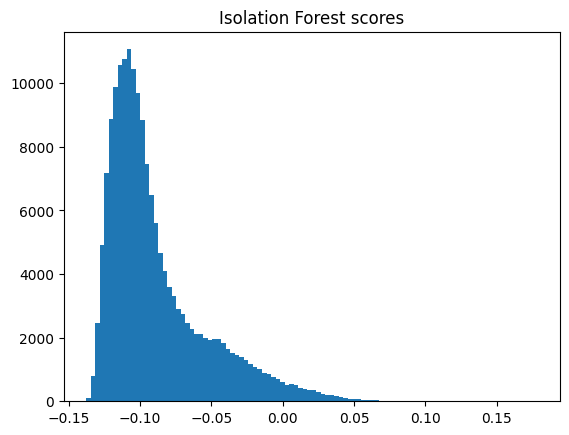

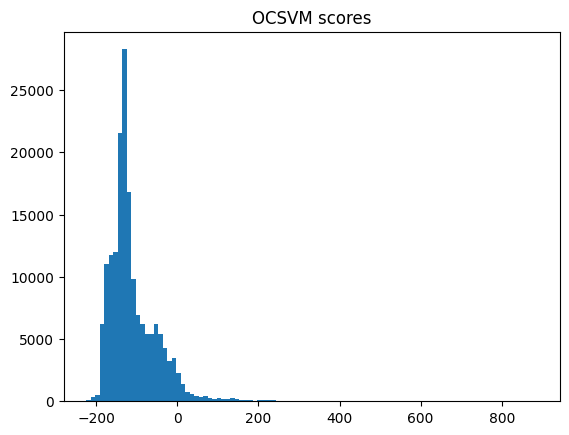

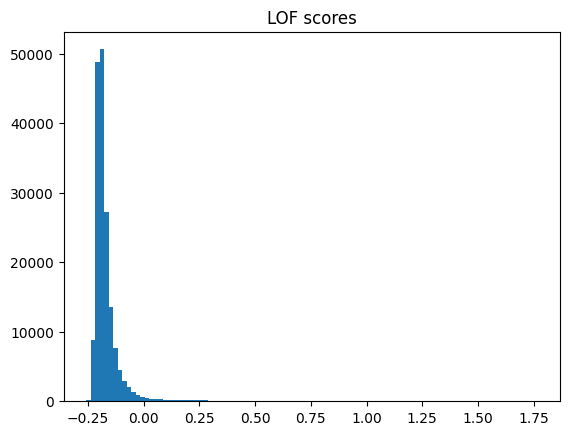

In [21]:
# cell 13 - score distribution sanity check
plt.hist(if_scores, bins=100); plt.title("Isolation Forest scores"); plt.show()
plt.hist(svm_scores, bins=100); plt.title("OCSVM scores"); plt.show()
plt.hist(lof_scores, bins=100); plt.title("LOF scores"); plt.show()

In [22]:
import os
output_dir = "/kaggle/working/thesis_results"
os.makedirs(output_dir, exist_ok=True)

# Audit stats function
def audit_stats_df(mask, X, model_name):
    stats = {
        "high_cost_rate": X.loc[mask, "high_cost_flag"].mean(),
        "zero_payment_rate": X.loc[mask, "zero_payment_flag"].mean(),
        "high_volume_provider_rate": X.loc[mask, "high_volume_provider_flag"].mean(),
        "avg_log_payment": X.loc[mask, "log_payment"].mean(),
        "count": int(mask.sum())
    }
    df = pd.DataFrame(stats, index=[model_name])
    return df

audit_if_df = audit_stats_df(mask_if, X, "IsolationForest")
audit_svm_df = audit_stats_df(mask_svm, X, "OCSVM")
audit_lof_df = audit_stats_df(mask_lof, X, "LOF")

audit_all_df = pd.concat([audit_if_df, audit_svm_df, audit_lof_df])
audit_all_df.to_csv(os.path.join(output_dir, "audit_stats.csv"))
print("Audit stats saved at:", os.path.join(output_dir, "audit_stats.csv"))

Audit stats saved at: /kaggle/working/thesis_results/audit_stats.csv


In [23]:
top_if = X.loc[mask_if]
top_svm = X.loc[mask_svm]
top_lof = X.loc[mask_lof]

top_if.to_csv(os.path.join(output_dir, "top_anomalies_if.csv"), index=False)
top_svm.to_csv(os.path.join(output_dir, "top_anomalies_svm.csv"), index=False)
top_lof.to_csv(os.path.join(output_dir, "top_anomalies_lof.csv"), index=False)

In [24]:
consensus_mask = mask_if & mask_svm
top_consensus = X.loc[consensus_mask]
top_consensus.to_csv(os.path.join(output_dir, "top_anomalies_consensus.csv"), index=False)
print("Consensus anomalies saved at:", os.path.join(output_dir, "top_anomalies_consensus.csv"))

Consensus anomalies saved at: /kaggle/working/thesis_results/top_anomalies_consensus.csv


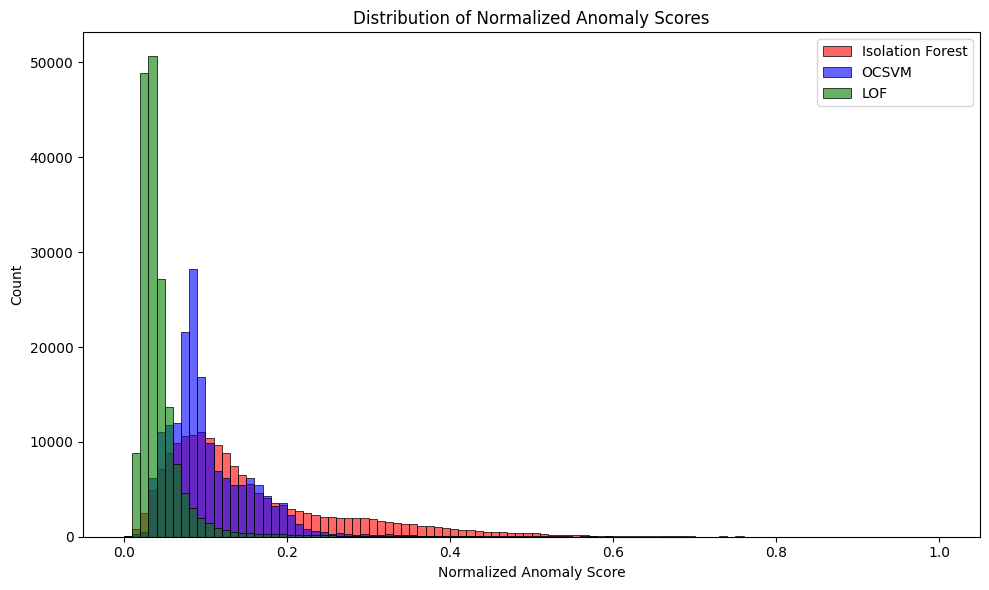

In [25]:
import numpy as np

# Min-max normalize scores for visualization
def normalize_scores(scores):
    return (scores - np.min(scores)) / (np.max(scores) - np.min(scores))

if_norm = normalize_scores(if_scores)
svm_norm = normalize_scores(svm_scores)
lof_norm = normalize_scores(lof_scores)

plt.figure(figsize=(10,6))
sns.histplot(if_norm, bins=100, color='red', label='Isolation Forest', alpha=0.6)
sns.histplot(svm_norm, bins=100, color='blue', label='OCSVM', alpha=0.6)
sns.histplot(lof_norm, bins=100, color='green', label='LOF', alpha=0.6)
plt.xlabel("Normalized Anomaly Score")
plt.ylabel("Count")
plt.title("Distribution of Normalized Anomaly Scores")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "anomaly_score_distribution.png"), dpi=300)
plt.show()

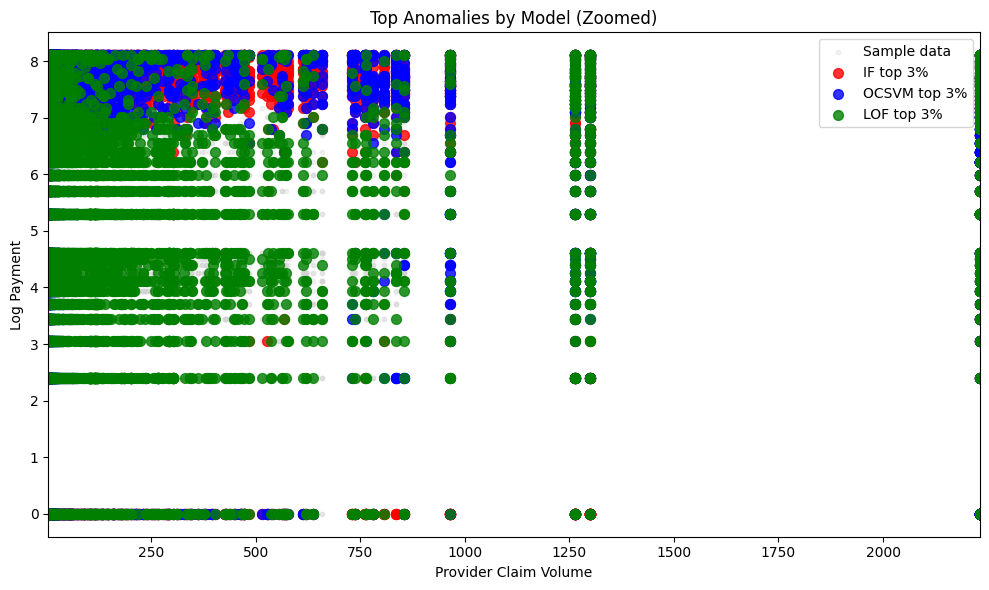

In [26]:
# Sample 10k points for background
X_bg = X.sample(10000, random_state=42)

plt.figure(figsize=(10,6))

# Background points in light grey
plt.scatter(X_bg["provider_claim_volume"], X_bg["log_payment"],
            color='lightgrey', alpha=0.3, s=10, label='Sample data')

# Top anomalies
plt.scatter(top_if["provider_claim_volume"], top_if["log_payment"], 
            color='red', alpha=0.8, s=50, label='IF top 3%')
plt.scatter(top_svm["provider_claim_volume"], top_svm["log_payment"], 
            color='blue', alpha=0.8, s=50, label='OCSVM top 3%')
plt.scatter(top_lof["provider_claim_volume"], top_lof["log_payment"], 
            color='green', alpha=0.8, s=50, label='LOF top 3%')

# Clip x-axis to 1st–99th percentile to avoid extreme spread
x_min, x_max = X["provider_claim_volume"].quantile([0.01, 0.99])
plt.xlim(x_min, x_max)

plt.xlabel("Provider Claim Volume")
plt.ylabel("Log Payment")
plt.title("Top Anomalies by Model (Zoomed)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "top_anomalies_scatter.png"), dpi=300)
plt.show()

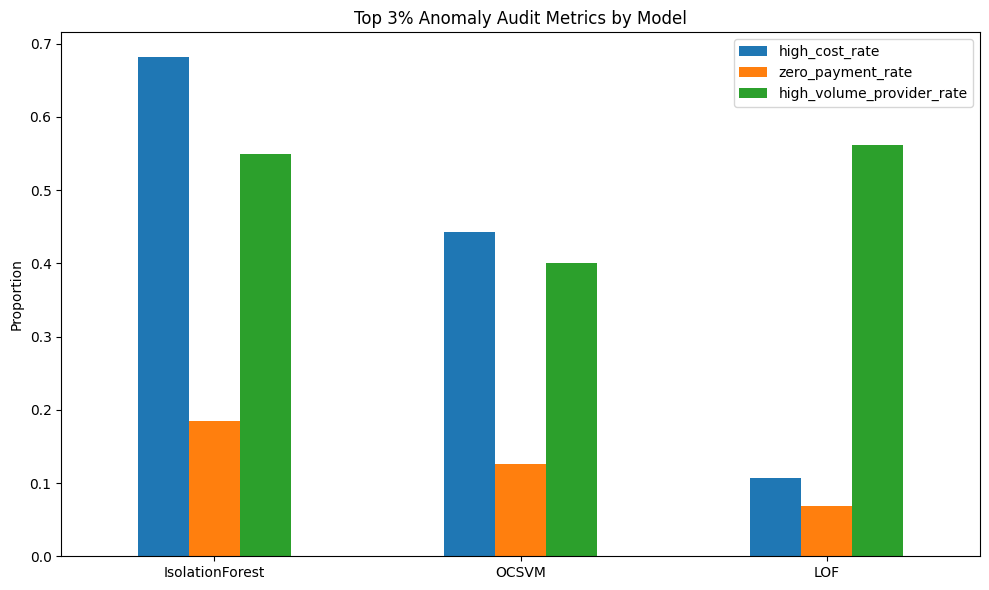

In [27]:
audit_plot = audit_all_df[["high_cost_rate","zero_payment_rate","high_volume_provider_rate"]]
audit_plot.plot(kind='bar', figsize=(10,6))
plt.title("Top 3% Anomaly Audit Metrics by Model")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "audit_metrics_bar.png"), dpi=300)
plt.show()

/tmp/ipykernel_24/3194158843.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="Set2")


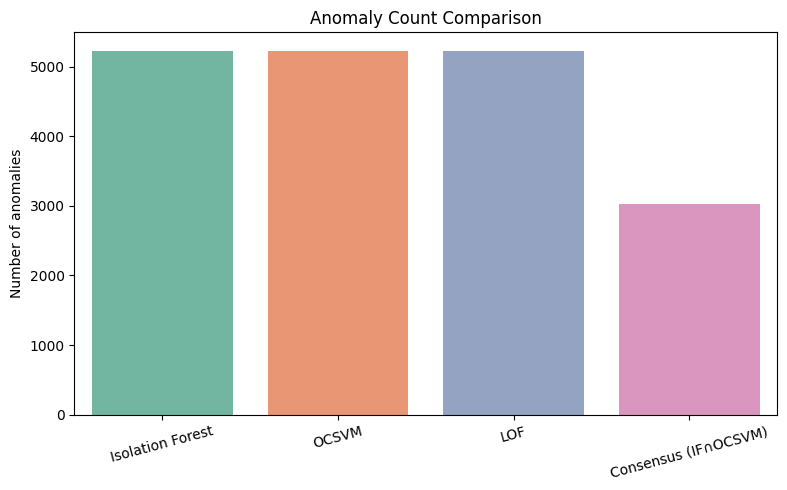

In [28]:
counts = {
    "Isolation Forest": mask_if.sum(),
    "OCSVM": mask_svm.sum(),
    "LOF": mask_lof.sum(),
    "Consensus (IF∩OCSVM)": consensus_mask.sum()
}

plt.figure(figsize=(8,5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="Set2")
plt.ylabel("Number of anomalies")
plt.title("Anomaly Count Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "anomaly_count_comparison.png"), dpi=300)
plt.show()

In [29]:
import shutil

# Path to your results folder
folder_to_zip = "/kaggle/working/thesis_results"
zip_path = "/kaggle/working/thesis_results.zip"

# Create zip
shutil.make_archive(zip_path.replace(".zip",""), 'zip', folder_to_zip)
print("Folder zipped at:", zip_path)

Folder zipped at: /kaggle/working/thesis_results.zip
